**Seeding for reproducibility**

In [1]:
# Set seeds for reproducibility
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

In [2]:
# role of SEED==Same dataset split, Same weight initialization..Each run same results
# we use random state as same concept but inside sklearn

**Importing the dependencies**

In [3]:
import os
import json
from zipfile import ZipFile
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

Upload the kaggle.json file

In [4]:
!pip install kaggle

Defaulting to user installation because normal site-packages is not writeable


In [5]:
kaggle_credentials = json.load(open("kaggle.json"))

In [6]:
# setup Kaggle API key as environment variables
os.environ['KAGGLE_USERNAME'] = kaggle_credentials["username"]
os.environ['KAGGLE_KEY'] = kaggle_credentials["key"]

In [7]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

'kaggle' is not recognized as an internal or external command,
operable program or batch file.


In [8]:
!ls

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [9]:
import os

# Define the path to your dataset (using 'r' before the string to handle backslashes)
data_dir = r"C:\Users\Jagdish singh\OneDrive\Desktop\placement\projectM\dataset\plantvillage dataset"

# List the subfolders (the plant disease classes)
if os.path.exists(data_dir):
    classes = os.listdir(data_dir)
    print(f"Successfully found {len(classes)} classes!")
    print("Top 5 classes:", classes[:5])
else:
    print("Error: The path is incorrect. Please double-check the folder location.")

Successfully found 3 classes!
Top 5 classes: ['color', 'grayscale', 'segmented']


In [10]:
import os

# Define the base directory
base_path = r"C:\Users\Jagdish singh\OneDrive\Desktop\placement\projectM\dataset\plantvillage dataset"

# 1. Check the main folder
print("Main Folders:", os.listdir(base_path))

# 2. Check Segmented
segmented_path = os.path.join(base_path, "segmented")
print(f"\nSegmented count: {len(os.listdir(segmented_path))}")
print("Samples:", os.listdir(segmented_path)[:5])

# 3. Check Color
color_path = os.path.join(base_path, "color")
print(f"\nColor count: {len(os.listdir(color_path))}")
print("Samples:", os.listdir(color_path)[:5])

# 4. Check Grayscale
grayscale_path = os.path.join(base_path, "grayscale")
print(f"\nGrayscale count: {len(os.listdir(grayscale_path))}")
print("Samples:", os.listdir(grayscale_path)[:5])

Main Folders: ['color', 'grayscale', 'segmented']

Segmented count: 38
Samples: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']

Color count: 38
Samples: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']

Grayscale count: 38
Samples: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [11]:
'''with ZipFile("plantvillage-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall()'''

'with ZipFile("plantvillage-dataset.zip", \'r\') as zip_ref:\n    zip_ref.extractall()'

In [12]:
'''print(os.listdir("plantvillage dataset"))


print(len(os.listdir("plantvillage dataset/segmented")))
print(os.listdir("plantvillage dataset/segmented")[:5])

print(len(os.listdir("plantvillage dataset/color")))
print(os.listdir("plantvillage dataset/color")[:5])

print(len(os.listdir("plantvillage dataset/grayscale")))
print(os.listdir("plantvillage dataset/grayscale")[:5])'''

'print(os.listdir("plantvillage dataset"))\n\n\nprint(len(os.listdir("plantvillage dataset/segmented")))\nprint(os.listdir("plantvillage dataset/segmented")[:5])\n\nprint(len(os.listdir("plantvillage dataset/color")))\nprint(os.listdir("plantvillage dataset/color")[:5])\n\nprint(len(os.listdir("plantvillage dataset/grayscale")))\nprint(os.listdir("plantvillage dataset/grayscale")[:5])'

**Number of Classes = 38**

In [13]:
import os

# 1. Define the "Master Path" once at the top
# Using the 'r' prefix prevents Windows backslash errors
BASE_DIR = r"C:\Users\Jagdish singh\OneDrive\Desktop\placement\projectM\dataset\plantvillage dataset"

# 2. Create sub-paths using os.path.join (Safest way to handle paths)
COLOR_DIR = os.path.join(BASE_DIR, "color")
SEGMENTED_DIR = os.path.join(BASE_DIR, "segmented")
GRAYSCALE_DIR = os.path.join(BASE_DIR, "grayscale")

# 3. Test a specific class safely
grape_healthy_path = os.path.join(COLOR_DIR, "Grape___healthy")

if os.path.exists(grape_healthy_path):
    print(f"Success! Found {len(os.listdir(grape_healthy_path))} images.")
    print("First 5 files:", os.listdir(grape_healthy_path)[:5])
else:
    print("Error: Path not found. Check if 'color' and 'Grape___healthy' exist inside the BASE_DIR.")

Success! Found 423 images.
First 5 files: ['00e00912-bf75-4cf8-8b7d-ad64b73bea5f___Mt.N.V_HL 6067.JPG', '0163a6aa-fbf8-47c5-965f-59b6efe8bfe5___Mt.N.V_HL 6103.JPG', '0294ca65-4c29-44be-af28-501df9f715e8___Mt.N.V_HL 6176.JPG', '02f95acb-5d92-4f2a-b7ec-3af8709ee7c9___Mt.N.V_HL 9078.JPG', '03027791-26bb-4c46-960e-8df76e27042c___Mt.N.V_HL 6070.JPG']


In [ ]:


# 1. Start from the 'dataset' folder seen in your sidebar
# Note: Use '/' even on Windows in Python, it's safer!
BASE_PATH = "dataset/plantvillage dataset"

# 2. Define the subfolders
COLOR_DIR = os.path.join(BASE_PATH, "color")

# 3. Access a specific plant
# Make sure there are THREE underscores like in the folder name
grape_folder = os.path.join(COLOR_DIR, "Grape___healthy")

# 4. The Test
if os.path.exists(grape_folder):
    print(f"✅ Success! Path found.")
    print(f"Total images in Grape folder: {len(os.listdir(grape_folder))}")
else:
    print("❌ Path not found!")
    # This part helps us debug if it fails
    print(f"I am looking here: {os.path.abspath(grape_folder)}")

✅ Success! Path found.
Total images in Grape folder: 423


In [17]:
'''print(len(os.listdir("plantvillage dataset/color/Grape___healthy")))
print(os.listdir("plantvillage dataset/color/Grape___healthy")[:5])'''

'print(len(os.listdir("plantvillage dataset/color/Grape___healthy")))\nprint(os.listdir("plantvillage dataset/color/Grape___healthy")[:5])'

**Data Preprocessing**

In [18]:
# Dataset Path
base_dir = 'plantvillage dataset/color'

Image Shape: (256, 256, 3)


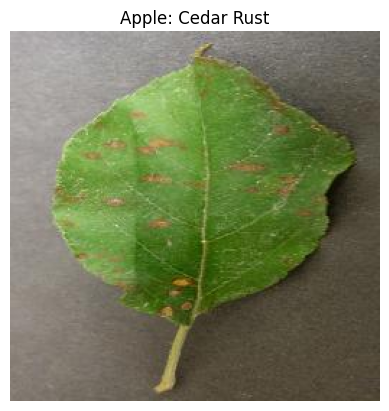

In [20]:
# CHANGED: Removed "/content/" and added "dataset/" at the start
image_path = r'dataset/plantvillage dataset/color/Apple___Cedar_apple_rust/025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655.JPG'

# Read the image
if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    print(f"Image Shape: {img.shape}")
    
    # Display the image
    plt.imshow(img)
    plt.axis('off')
    plt.title("Apple: Cedar Rust")
    plt.show()
else:
    print("❌ Still can't find that specific image file.")
    print("Double check if the filename has any extra spaces!")

In [22]:
image_path = r'dataset/plantvillage dataset/color/Apple___Cedar_apple_rust/025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655.JPG'

# Read the image
img = mpimg.imread(image_path)

print(img)

[[[179 175 176]
  [181 177 178]
  [184 180 181]
  ...
  [115 112 105]
  [108 105  98]
  [101  98  91]]

 [[176 172 173]
  [177 173 174]
  [178 174 175]
  ...
  [113 110 103]
  [111 108 101]
  [109 106  99]]

 [[180 176 177]
  [180 176 177]
  [180 176 177]
  ...
  [108 105  98]
  [111 108 101]
  [114 111 104]]

 ...

 [[137 128 119]
  [131 122 113]
  [125 116 107]
  ...
  [ 74  65  48]
  [ 74  65  48]
  [ 73  64  47]]

 [[136 127 118]
  [132 123 114]
  [128 119 110]
  ...
  [ 77  69  50]
  [ 75  67  48]
  [ 75  67  48]]

 [[133 124 115]
  [133 124 115]
  [132 123 114]
  ...
  [ 81  73  54]
  [ 80  72  53]
  [ 79  71  52]]]


In [26]:
img.shape

(256, 256, 3)

In [25]:
height, width, channels = img.shape
img_size = height 
print(f"Original Image Height: {height}")
print(f"Original Image Width: {width}")
print(f"Color Channels: {channels}")

Original Image Height: 256
Original Image Width: 256
Color Channels: 3


In [23]:
# Image Parameters
img_size = 224
batch_size = 32

**Train Test Split**

In [ ]:
# Image Data Generators
data_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 20%
)

In [ ]:
# Train Generator
train_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

Found 43456 images belonging to 38 classes.


In [ ]:
# Validation Generator
validation_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical'
)

Found 10849 images belonging to 38 classes.


**Convolutional Neural Network**

In [ ]:
# Model Definition
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))


model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(train_generator.num_classes, activation='softmax'))

In [ ]:
# model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 186624)            0         
                                                                 
 dense (Dense)               (None, 256)               4

In [ ]:
# Compile the Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

**Model training**

In [ ]:
# Training the Model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,  # Number of steps per epoch
    epochs=5,  # Number of epochs
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size  # Validation steps
)

Epoch 1/5
1358/1358 [==============================] - 108s 76ms/step - loss: 0.9791 - accuracy: 0.7328 - val_loss: 0.4846 - val_accuracy: 0.8465
Epoch 2/5
1358/1358 [==============================] - 104s 77ms/step - loss: 0.2812 - accuracy: 0.9110 - val_loss: 0.4477 - val_accuracy: 0.8655
Epoch 3/5
1358/1358 [==============================] - 106s 78ms/step - loss: 0.1362 - accuracy: 0.9553 - val_loss: 0.4321 - val_accuracy: 0.8863
Epoch 4/5
1358/1358 [==============================] - 103s 76ms/step - loss: 0.0891 - accuracy: 0.9708 - val_loss: 0.5433 - val_accuracy: 0.8715
Epoch 5/5
1358/1358 [==============================] - 109s 81ms/step - loss: 0.0761 - accuracy: 0.9760 - val_loss: 0.5091 - val_accuracy: 0.8828


**Model Evaluation**

In [ ]:
# Model Evaluation
print("Evaluating model...")
val_loss, val_accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Evaluating model...
339/339 [==============================] - 19s 57ms/step - loss: 0.5091 - accuracy: 0.8828
Validation Accuracy: 88.28%


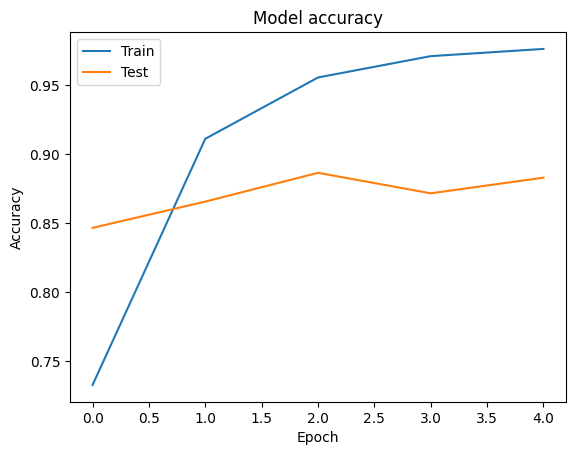

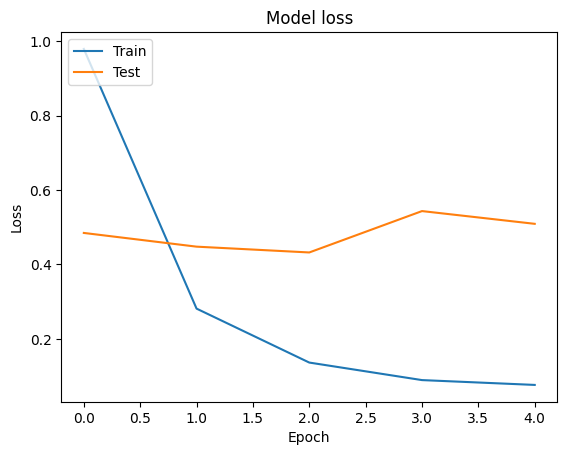

In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

**Building a Predictive System**

In [ ]:
# Function to Load and Preprocess the Image using Pillow
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    # Load the image
    img = Image.open(image_path)
    # Resize the image
    img = img.resize(target_size)
    # Convert the image to a numpy array
    img_array = np.array(img)
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    # Scale the image values to [0, 1]
    img_array = img_array.astype('float32') / 255.
    return img_array

# Function to Predict the Class of an Image
def predict_image_class(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image(image_path)
    predictions = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name

In [ ]:
# Create a mapping from class indices to class names
class_indices = {v: k for k, v in train_generator.class_indices.items()}

In [ ]:
class_indices

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [ ]:
# saving the class names as json file
json.dump(class_indices, open('class_indices.json', 'w'))

In [ ]:
# Example Usage
image_path = '/content/test_apple_black_rot.JPG'
#image_path = '/content/test_blueberry_healthy.jpg'
#image_path = '/content/test_potato_early_blight.jpg'
predicted_class_name = predict_image_class(model, image_path, class_indices)

# Output the result
print("Predicted Class Name:", predicted_class_name)

1/1 [==============================] - 0s 266ms/step
Predicted Class Name: Apple___Black_rot


**Save the model to Google drive or local**

In [ ]:
model.save('drive/MyDrive/Youtube/trained_models/plant_disease_prediction_model.h5')

In [ ]:
model.save('plant_disease_prediction_model.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
